## Configuración e importación de librerías

Carga y manipulación de datos

In [19]:

import pandas as pd
import numpy as np
import os
from datetime import datetime
from pathlib import Path
import time

Datos espaciales - vectores

In [20]:
import geopandas as gpd

Modelado y aprendizaje automático

In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Intentamos importar las librerías de Boosting
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
except ImportError:
    print("⚠️ ADVERTENCIA: Faltan librerías de Boosting. Ejecuta: pip install xgboost lightgbm catboost")

Evaluación del modelo

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)

Visualización

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

Serialización y persistencia

In [24]:
import pickle

Fijar semillas aleatorias para reproducibilidad

In [25]:
seed = 42
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

Rutas a la carpetas de datos

In [26]:
DATA_DIR = Path("data-test")
DATASET_COMPLETO = DATA_DIR / "Dataset_Completo_Cordillera_V1.csv"
## el de ingenería ya está curado
DATASET_INGENIERIA = DATA_DIR / "Dataset_Cordillera_Ingenieria.csv"
DATASET_FOCOS = DATA_DIR / "Dataset_Focos_de_calor_2018_2023.csv"

if DATASET_COMPLETO.exists():
    print(f"Dataset consolidado encontrado: {DATASET_COMPLETO.name}")
    print("Las variables climáticas, topográficas y de vegetación ya están integradas.")
else:
    print(f"ERROR CRÍTICO: No se encontró el archivo {DATASET_COMPLETO}. Verifica la carpeta data-test.")

# --- MANTENEMOS LAS RUTAS A LOS SHAPEFILES ---
SHP_DIR = Path("data") / "COORDILLERA"
DEPARTAMENTO_SHP_PATH = SHP_DIR / "Departamento_Coordillera.shp"
VIAS_SHP_PATH = SHP_DIR / "Vias_principales_Coordillera.shp"
CIUDADES_SHP_PATH = SHP_DIR / "Ciudades_Coordillera.shp"

# --- CONFIGURACIÓN DE SALIDAS ---
TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
OUTPUT_DIR = Path("outputs") / TIMESTAMP
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Los resultados y modelos se guardarán en: {OUTPUT_DIR}")

Dataset consolidado encontrado: Dataset_Completo_Cordillera_V1.csv
Las variables climáticas, topográficas y de vegetación ya están integradas.
Los resultados y modelos se guardarán en: outputs\2026-04-09_11-40-36


## Funciones auxiliares

In [ ]:
def cargar_dataset_final(path_completo, path_ingenieria=None):
    """
    Carga el dataset consolidado y realiza la ingeniería de variables 
    finales para el modelado. Esto incluye la conversión de componentes vectoriales del viento, 
    la extracción de características temporales y la integración de variables de ingeniería adicionales.
    """
    print("\n--- CARGANDO Y PROCESANDO DATASET (INGENIERÍA FINAL) ---")
    
    # 1. Carga del archivo principal
    df = pd.read_csv(path_completo)
    print(f"Dataset principal cargado: {len(df)} registros.")

    # 2. Asegurar formato de fecha
    df['fecha'] = pd.to_datetime(df['fecha'])
    
    # 3. INGENIERÍA DEL VIENTO 
    # Convertimos componentes vectoriales U y V en la velocidad real (magnitud)
    # Esto es vital para que el modelo entienda la fuerza del viento.
    if 'viento_u' in df.columns and 'viento_v' in df.columns:
        print("Calculando magnitud vectorial del viento (sqrt(u^2 + v^2))...")
        df['viento_velocidad'] = np.sqrt(df['viento_u']**2 + df['viento_v']**2)
    
    # 4. INGENIERÍA DEL TIEMPO (Estacionalidad Cíclica)
    # Extraemos el mes y lo convertimos a coordenadas sin/cos
    # Esto ayuda al modelo a entender que diciembre (12) y enero (1) están cerca.
    df['mes'] = df['fecha'].dt.month
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

    # 5. Integración de ingeniería externa (si existe)
    if path_ingenieria and path_ingenieria.exists():
        print("Integrando variables de ingeniería adicionales desde archivo curado...")
        # Aquí puedes cargar y unir si el archivo de ingeniería tiene columnas extra
        # como dist_vias o dist_ciudades que no estén en el consolidado.
        df_ing = pd.read_csv(path_ingenieria)
        # (Opcional: lógica de merge si fuera necesario)

    # 6. Limpieza final y selección de tipos
    # Eliminamos nulos y aseguramos que 'cobertura_suelo' sea categórica
    df = df.dropna()
    if 'cobertura_suelo' in df.columns:
        df['cobertura_suelo'] = df['cobertura_suelo'].astype('category')
    
    print("Variables listas para ML:", df.columns.tolist())
    print("Fase de preparación completada con éxito.")
    
    return df

## Generación de la muestra y asignación de datos

In [28]:
print("\n--- INICIANDO FASE DE PREPARACIÓN DE DATOS (INGENIERÍA SEGÚN TESIS) ---")

# 1. Cargar y procesar el dataset usando la función con ingeniería de variables
# Esta función ya calcula la magnitud del viento (Pág. 44) y los meses cíclicos.
full_dataset = cargar_dataset_final(DATASET_COMPLETO, DATASET_INGENIERIA)

# 2. Verificación de equilibrio de clases (Clave para la validez estadística)
conteo_clases = full_dataset['clase'].value_counts()
print(f"Dataset procesado y curado exitosamente:")
print(f"  - Registros de Incendio (Clase 1): {conteo_clases.get(1, 0)}")
print(f"  - Registros de No-Incendio (Clase 0): {conteo_clases.get(0, 0)}")

# 3. Cargar el área de estudio (Solo para referencia geográfica o mapas)
try:
    area_estudio_gdf = gpd.read_file(DEPARTAMENTO_SHP_PATH)
    CRS_REFERENCE = area_estudio_gdf.crs.to_string()
    print(f"Área de estudio (Cordillera) cargada. CRS: {CRS_REFERENCE}")
except Exception as e:
    print(f"Nota: No se pudo cargar el SHP de referencia, pero el dataset alfanumérico está listo.")

# 4. Verificación final de integridad
# Como cargar_dataset_final ya hace dropna(), aquí solo confirmamos.
print(f"Total de registros listos para entrenamiento: {len(full_dataset)}")
print(f"Columnas finales incluidas: {full_dataset.columns.tolist()}")

print("\n--- PREPARACIÓN FINALIZADA. DATOS LISTOS PARA EVALUACIÓN ---")


--- INICIANDO FASE DE PREPARACIÓN DE DATOS (INGENIERÍA SEGÚN TESIS) ---

--- CARGANDO Y PROCESANDO DATASET (INGENIERÍA FINAL) ---
Dataset principal cargado: 45076 registros.
Calculando magnitud vectorial del viento (sqrt(u^2 + v^2))...
Integrando variables de ingeniería adicionales desde archivo curado...
Variables listas para ML: ['clase', 'fecha', 'longitude', 'latitude', 'temp_max_c', 'humedad_min_pct', 'precip_diaria_mm', 'precip_7dias_mm', 'viento_u', 'viento_v', 'elevation', 'pendiente', 'orientacion', 'ndvi_mensual', 'cobertura_suelo', 'viento_velocidad', 'mes', 'mes_sin', 'mes_cos']
Fase de preparación completada con éxito.
Dataset procesado y curado exitosamente:
  - Registros de Incendio (Clase 1): 22064
  - Registros de No-Incendio (Clase 0): 22193
Área de estudio (Cordillera) cargada. CRS: EPSG:4674
Total de registros listos para entrenamiento: 44257
Columnas finales incluidas: ['clase', 'fecha', 'longitude', 'latitude', 'temp_max_c', 'humedad_min_pct', 'precip_diaria_mm',

## Depuración y modelado

In [29]:
import io

print("\n--- INICIANDO FASE DE DEPURACIÓN Y AUDITORÍA DE DATOS ---")

# 1. Verificar nulos ANTES de la selección final (Auditoría de Calidad)
print("Valores nulos por columna detectados:\n", full_dataset.isnull().sum())

# 2. Limpiar el dataset
# Nota: full_dataset ya viene de cargar_dataset_final, pero aseguramos integridad.
datos_depurados = full_dataset.dropna().copy()
print(f"\nRegistros totales para el análisis: {len(datos_depurados)}")

# Validación de seguridad académica
if len(datos_depurados) < 100:
    print("\nERROR CRÍTICO: No hay suficientes datos para una validación estadística robusta.")

# 3. SELECCIÓN DE COLUMNAS DEFINITIVAS (Alineado con Pág. 44 del PDF)
# Reemplazamos viento_u/v por viento_velocidad y añadimos meses cíclicos
columnas_modelo = [
    'clase',              # Variable objetivo
    'elevation', 'pendiente', 'orientacion', # Topografía
    'temp_max_c', 'humedad_min_pct',         # Clima crítico
    'precip_diaria_mm', 'precip_7dias_mm', 
    'viento_velocidad',   # Magnitud real (Requisito Tesis)
    'ndvi_mensual',       # Estado de la vegetación
    'cobertura_suelo',    # Uso de suelo (ESA WorldCover)
    'mes_sin', 'mes_cos'  # Estacionalidad cíclica
]

# Creamos el dataset final que entrará a los modelos de evaluación
datos_modelo = datos_depurados[columnas_modelo].copy()

# 4. TRATAMIENTO DE CATEGORÍAS Y TIPOS
# 'cobertura_suelo' debe ser categoría para que el preprocesador lo trate como One-Hot o Label
datos_modelo['cobertura_suelo'] = datos_modelo['cobertura_suelo'].astype('category')

print("\n✅ Estructura final del dataset para evaluación multicriterio:")
datos_modelo.info()

# 5. GUARDAR REPORTE TÉCNICO EN EL DISCO
# Este archivo servirá como anexo para tu tesis sobre la calidad de los datos usados.
buffer = io.StringIO()
datos_modelo.info(buf=buffer)
info_string = buffer.getvalue()

ruta_resumen_dataset = OUTPUT_DIR / "auditoria_dataset_final.txt"
with open(ruta_resumen_dataset, "w", encoding="utf-8") as f:
    f.write("==================================================\n")
    f.write(" AUDITORÍA DEL DATASET FINAL - TESIS 2026\n")
    f.write("==================================================\n\n")
    f.write(f"Fecha de generación: {datetime.now()}\n")
    f.write(f"Total de muestras: {len(datos_modelo)}\n")
    f.write(f"Balance de Clases:\n{datos_modelo['clase'].value_counts().to_string()}\n\n")
    f.write("--- INFO TÉCNICA DE COLUMNAS ---\n")
    f.write(info_string)
    f.write("\n--- VISTA PREVIA DE DATOS CURADOS ---\n")
    f.write(datos_modelo.head(10).to_string())

print(f"\nAuditoría técnica guardada en: {ruta_resumen_dataset}")


--- INICIANDO FASE DE DEPURACIÓN Y AUDITORÍA DE DATOS ---
Valores nulos por columna detectados:
 clase               0
fecha               0
longitude           0
latitude            0
temp_max_c          0
humedad_min_pct     0
precip_diaria_mm    0
precip_7dias_mm     0
viento_u            0
viento_v            0
elevation           0
pendiente           0
orientacion         0
ndvi_mensual        0
cobertura_suelo     0
viento_velocidad    0
mes                 0
mes_sin             0
mes_cos             0
dtype: int64

Registros totales para el análisis: 44257

✅ Estructura final del dataset para evaluación multicriterio:
<class 'pandas.core.frame.DataFrame'>
Index: 44257 entries, 0 to 45075
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   clase             44257 non-null  int64   
 1   elevation         44257 non-null  int64   
 2   pendiente         44257 non-null  float64 
 3   orientacion     

## Modelado con validación temporal

In [ ]:
print("\n--- INICIANDO FASE DE MODELADO CON VALIDACIÓN TEMPORAL (2018-2022 / 2023) ---")

# 1. Recuperamos el año para el Split Temporal
# Usamos el índice para asegurar que coincida con datos_modelo
datos_modelo['anio'] = datos_depurados.loc[datos_modelo.index, 'fecha'].dt.year

# 2. División TEMPORAL (Requisito para evitar fuga de datos en series temporales)
train_df = datos_modelo[datos_modelo['anio'] <= 2022].copy()
test_df = datos_modelo[datos_modelo['anio'] == 2023].copy()

# 3. Preparación de X e y (Eliminamos 'anio' para que no sea una variable predictora)
X_train = train_df.drop(columns=['clase', 'anio'])
y_train = train_df['clase']
X_test = test_df.drop(columns=['clase', 'anio'])
y_test = test_df['clase']

print(f"Dataset dividido: Train (2018-2022): {len(X_train)} | Test (2023): {len(X_test)}")

# 4. Configuración del Preprocesamiento 
# Escalamos números y codificamos categorías (cobertura_suelo)
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category']).columns.tolist()
# One con-hot encode para 'cobertura_suelo' y escalado para las variables numéricas, 
# todo integrado en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Definición de Modelos Individuales (Tus 'Alternativas' para TOPSIS)
# He incluido los algoritmos que mencionas en la Pág. 30 de tu marco teórico.
modelos_base = {
    'RF': RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1, random_state=seed),
    'LGBM': LGBMClassifier(n_estimators=100, verbose=-1, n_jobs=-1, random_state=seed),
    'SVM': CalibratedClassifierCV(LinearSVC(dual='auto', random_state=seed)),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'CAT': CatBoostClassifier(iterations=100, learning_rate=0.1, verbose=0, random_state=seed),
    'MLP': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=seed)
}

# 6. Entrenamiento y Almacenamiento de Modelos
# Creamos un diccionario para guardar los modelos entrenados
pipelines_entrenados = {}

print("\nEntrenando modelos individuales para evaluación multicriterio...")
for nombre, modelo in modelos_base.items():
    # Creamos un pipeline para cada modelo para que el preprocesamiento sea automático
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipeline
    print(f"✅ Modelo {nombre} entrenado con éxito.")

print("\n--- FASE DE ENTRENAMIENTO COMPLETADA ---")


--- INICIANDO FASE DE MODELADO CON VALIDACIÓN TEMPORAL (2018-2022 / 2023) ---
Dataset dividido: Train (2018-2022): 37119 | Test (2023): 7138

Entrenando modelos individuales para evaluación multicriterio...
✅ Modelo RF entrenado con éxito.
✅ Modelo XGB entrenado con éxito.
✅ Modelo LGBM entrenado con éxito.
✅ Modelo SVM entrenado con éxito.
✅ Modelo KNN entrenado con éxito.
✅ Modelo CAT entrenado con éxito.
✅ Modelo MLP entrenado con éxito.

--- FASE DE ENTRENAMIENTO COMPLETADA ---


### EVALUACIÓN UNIFICADA (MÉTRICAS + TIEMPO + MEMORIA)

In [31]:
import time
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("\n--- RECOPILANDO MÉTRICAS PARA EVALUACIÓN MULTICRITERIO (AHP-TOPSIS) ---")

resultados_globales = []

# Evaluamos cada pipeline (Preprocesador + Modelo) que guardamos antes
for nombre, pipeline in pipelines_entrenados.items():
    print(f"Evaluando rendimiento de: {nombre}...")
    
    # 1. Medir Tiempo de Inferencia (Criterio de Costo para TOPSIS)
    # Medimos cuánto tarda en predecir sobre todo el set de test de 2023
    start_time = time.time()
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    end_time = time.time()
    
    tiempo_inferencia = end_time - start_time
    
    # 2. Calcular Métricas Estadísticas (Criterios de Beneficio según Pág. 30-31)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0) # Recall = Sensibilidad
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # Especificidad (Capacidad de detectar correctamente zonas sin incendio)
    # Requisito común en estudios de riesgo forestal
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # 3. Medir Memoria / Peso del Modelo (Criterio de Costo)
    # Calculamos el peso en MB del archivo del modelo serializado
    peso_mb = len(pickle.dumps(pipeline)) / (1024 * 1024)

    # 4. Guardar resultados para la Matriz de Decisión
    resultados_globales.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'ROC_AUC': auc,
        'Specificity': spec,
        'Tiempo_Inferencia': tiempo_inferencia,
        'Memoria_MB': peso_mb,
        'y_proba': y_proba  # Guardamos probabilidades para las curvas ROC finales
    })

# Creamos el DataFrame resumen
df_resultados = pd.DataFrame(resultados_globales).set_index('Modelo')

# Mostramos el resumen limpio (sin la columna de y_proba)
print("\n✅ Matriz de Decisión Generada:")
columnas_vista = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'Specificity', 'Tiempo_Inferencia', 'Memoria_MB']
print(df_resultados[columnas_vista].round(4))

# Guardar en CSV para el análisis AHP-TOPSIS
ruta_csv_resultados = OUTPUT_DIR / "metricas_comparativas_modelos.csv"
df_resultados.to_csv(ruta_csv_resultados)

print(f"\nResultados exportados a: {ruta_csv_resultados}")
print("Esta tabla será la entrada directa para el algoritmo TOPSIS.")


--- RECOPILANDO MÉTRICAS PARA EVALUACIÓN MULTICRITERIO (AHP-TOPSIS) ---
Evaluando rendimiento de: RF...
Evaluando rendimiento de: XGB...
Evaluando rendimiento de: LGBM...


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluando rendimiento de: SVM...
Evaluando rendimiento de: KNN...
Evaluando rendimiento de: CAT...
Evaluando rendimiento de: MLP...

✅ Matriz de Decisión Generada:
        Accuracy  Precision  Recall  F1_Score  ROC_AUC  Specificity  \
Modelo                                                                
RF        0.7163     0.8714  0.4803    0.6193   0.8682       0.9345   
XGB       0.7941     0.8379  0.7084    0.7677   0.8853       0.8733   
LGBM      0.7793     0.8472  0.6597    0.7418   0.8814       0.8900   
SVM       0.7897     0.7977  0.7533    0.7749   0.8809       0.8234   
KNN       0.7658     0.7697  0.7311    0.7499   0.8420       0.7978   
CAT       0.7946     0.8271  0.7238    0.7720   0.8872       0.8601   
MLP       0.7190     0.8016  0.5515    0.6534   0.8147       0.8738   

        Tiempo_Inferencia  Memoria_MB  
Modelo                                 
RF                  0.469     56.5119  
XGB                 0.170      0.3371  
LGBM                0.362      0.336

### Implementación de Metodología AHP/Experto + TOPSIS

In [32]:
print("\n--- 4. ANÁLISIS MULTICRITERIO INTEGRADO: AHP + TOPSIS ---")

# -------------------------------------------------------------------------
# PASO 1: PONDERACIÓN DE CRITERIOS MEDIANTE AHP
# -------------------------------------------------------------------------
# Criterios en orden de la matriz de decisión
criterios_orden = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'Specificity', 'Tiempo_Inferencia', 'Memoria_MB']
n = len(criterios_orden)

# Matriz de Comparación por Pares 
# Justificación: Se otorga máxima prioridad al RECALL (Detección de incendios reales)
A = np.array([
# Acc    Prec   Rec    F1     AUC    Spec   Time   Mem
[ 1,     1/2,   1/5,   1/4,   1/3,   1/2,   5,     5],   # Accuracy
[ 2,     1,     1/4,   1/3,   1/2,   1,     5,     5],   # Precision
[ 5,     4,     1,     3,     3,     4,     7,     7],   # Recall (Prioridad Máxima)
[ 4,     3,     1/3,   1,     2,     3,     6,     6],   # F1_Score
[ 3,     2,     1/3,   1/2,   1,     2,     6,     6],   # ROC_AUC
[ 2,     1,     1/4,   1/3,   1/2,   1,     5,     5],   # Specificity
[ 1/5,   1/5,   1/7,   1/6,   1/6,   1/5,   1,     1],   # Tiempo_Inferencia (Costo)
[ 1/5,   1/5,   1/7,   1/6,   1/6,   1/5,   1,     1]    # Memoria_MB (Costo)
])

# Cálculo de Pesos (Método del Vector Propio -
eigenvalues, eigenvectors = np.linalg.eig(A)
max_index = np.argmax(eigenvalues.real)
lambda_max = eigenvalues.real[max_index]
weights_ahp = eigenvectors[:, max_index].real
weights_ahp = weights_ahp / weights_ahp.sum() 

# Validación de Consistencia 
CI = (lambda_max - n) / (n - 1)
RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.9, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41}
CR = CI / RI_dict[n]

print(f">>> Consistencia AHP (Saaty): CR = {CR:.4f}")
if CR < 0.1:
    print("✅ Resultado Académico: Matriz Consistente.")
else:
    print("⚠️ Advertencia: CR >= 0.1, revisar juicios de valor en la matriz A.")

# -------------------------------------------------------------------------
# PASO 2: FORMULACIÓN DE TOPSIS
# -------------------------------------------------------------------------
# 1. Preparar la Matriz de Decisión (X)
X_matriz = df_resultados[criterios_orden].copy()

# Estabilización de escala para variables de costo (Tiempo y Memoria)
# Esto evita que valores atípicos dominen el análisis
X_matriz['Tiempo_Inferencia'] = np.log1p(X_matriz['Tiempo_Inferencia'])
X_matriz['Memoria_MB'] = np.log1p(X_matriz['Memoria_MB'])

# Definir naturaleza de criterios (1=Beneficio, -1=Costo)
tipos = np.array([1, 1, 1, 1, 1, 1, -1, -1])

# 2. Normalización Vectorial 
# rij = xij / sqrt(sum(xkj^2))
X_norm = X_matriz / np.sqrt((X_matriz**2).sum())

# 3. Matriz Normalizada Ponderada 
# vij = wj * rij
V = X_norm * weights_ahp

# 4. Soluciones Ideales Positiva (A*) y Negativa (A-) 
ideal_pos = []
ideal_neg = []

for i, col in enumerate(criterios_orden):
    if tipos[i] == 1: # Criterio de Beneficio
        ideal_pos.append(V[col].max())
        ideal_neg.append(V[col].min())
    else: # Criterio de Costo
        ideal_pos.append(V[col].min())
        ideal_neg.append(V[col].max())

# 5. Distancias Euclidianas 
dist_pos = np.sqrt(((V - ideal_pos) ** 2).sum(axis=1))
dist_neg = np.sqrt(((V - ideal_neg) ** 2).sum(axis=1))

# Ci* = Si- / (Si* + Si-)
topsis_score = dist_neg / (dist_pos + dist_neg)

# -------------------------------------------------------------------------
# PASO 3: RANKING FINAL Y RESULTADOS
# -------------------------------------------------------------------------
df_ranking = df_resultados[criterios_orden].copy()
df_ranking['TOPSIS_Score'] = topsis_score
df_ranking['Rank'] = df_ranking['TOPSIS_Score'].rank(ascending=False).astype(int)
df_ranking = df_ranking.sort_values('Rank')

print("\n === RANKING FINAL DE MODELOS (ORDENADOS POR IDONEIDAD) ===")
# Resaltamos con colores: Verde es mejor, Rojo es peor.
display(df_ranking.style.background_gradient(cmap='RdYlGn', subset=['TOPSIS_Score', 'Recall']))

# Guardar para la memoria de la tesis
df_ranking.to_csv(OUTPUT_DIR / "ranking_modelos_ahp_topsis.csv")
print(f"\n✅ Análisis completado. El modelo ganador es: {df_ranking.index[0]}")


--- 4. ANÁLISIS MULTICRITERIO INTEGRADO: AHP + TOPSIS ---
>>> Consistencia AHP (Saaty): CR = 0.0450
✅ Resultado Académico: Matriz Consistente.

 === RANKING FINAL DE MODELOS (ORDENADOS POR IDONEIDAD) ===


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,Tiempo_Inferencia,Memoria_MB,TOPSIS_Score,Rank
Modelo,,,,,,,,,,
SVM,0.789717,0.797715,0.753281,0.774861,0.880938,0.823403,0.107003,0.004764,0.917516,1
CAT,0.794620,0.827058,0.723826,0.772006,0.887171,0.860070,0.261004,0.116582,0.888176,2
XGB,0.794060,0.837875,0.708370,0.767699,0.885281,0.873281,0.170004,0.337126,0.854978,3
LGBM,0.779350,0.847191,0.659668,0.741761,0.881414,0.889997,0.362002,0.336176,0.712056,4
KNN,0.765761,0.769727,0.731117,0.749925,0.841968,0.797789,4.004002,5.666506,0.659650,5
MLP,0.718969,0.801611,0.551473,0.653421,0.814666,0.873820,0.040995,0.085567,0.455588,6
RF,0.716307,0.871429,0.480315,0.619289,0.868194,0.934484,0.468992,56.511925,0.245632,7



✅ Análisis completado. El modelo ganador es: SVM


### VISUALIZACIÓN DE RESULTADOS

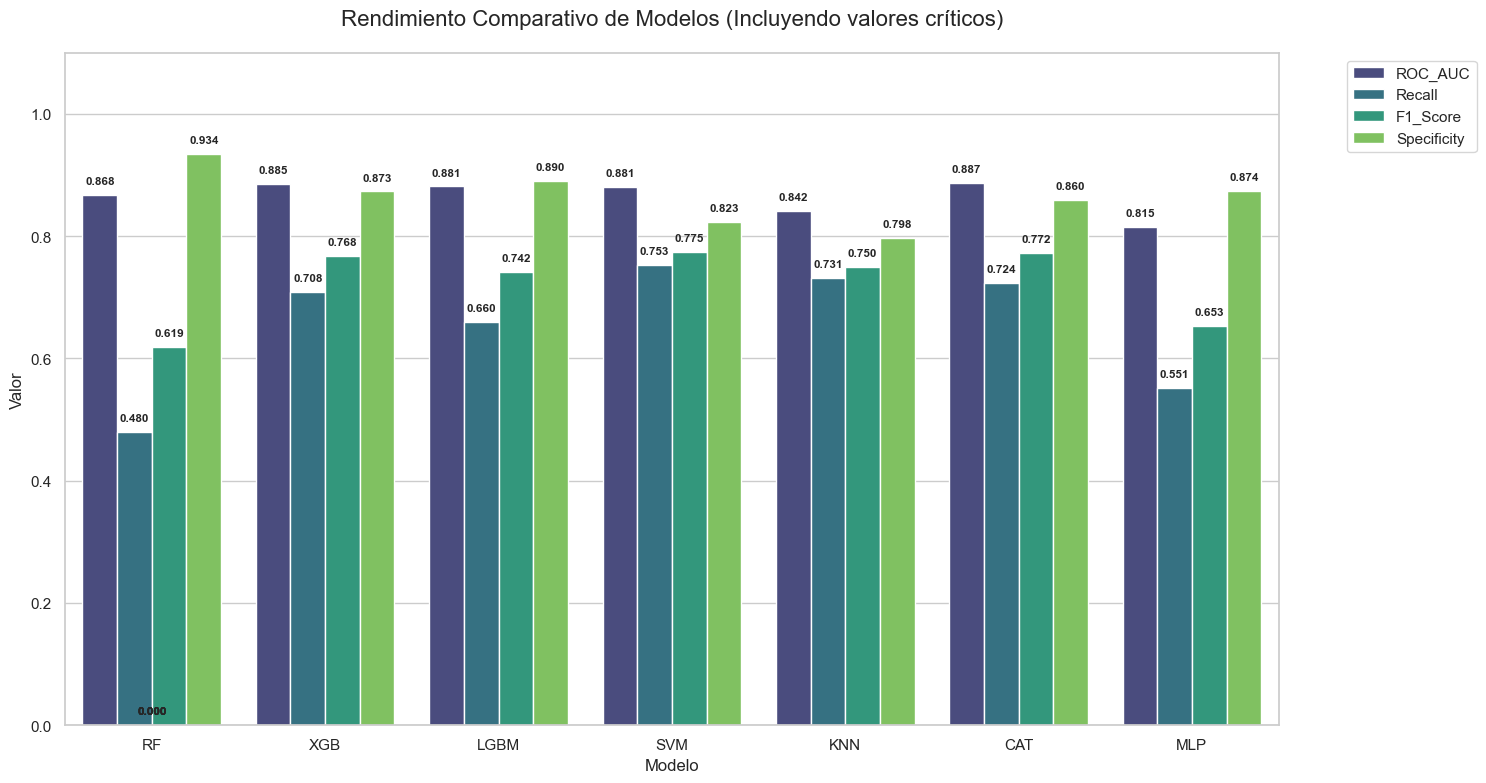

C:\Users\usuario\AppData\Local\Temp\ipykernel_17064\1932270703.py:58: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\usuario\AppData\Local\Temp\ipykernel_17064\1932270703.py:60: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(OUTPUT_DIR / "curvas_roc_comparativas.png", dpi=300)
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


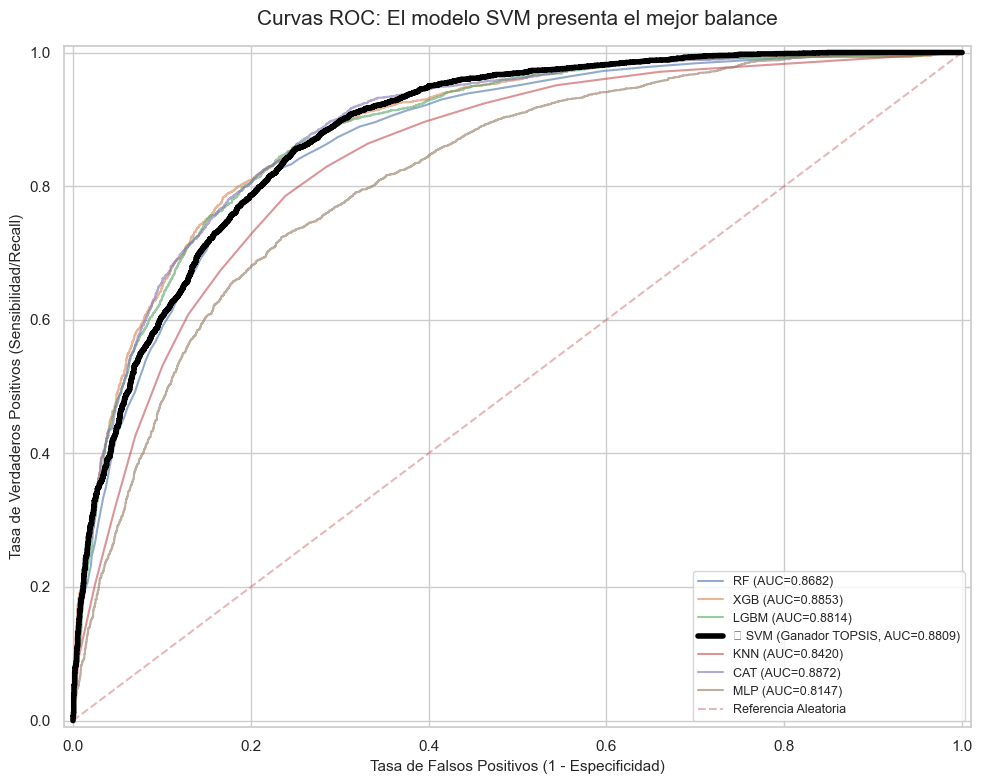

El ganador SVM no soporta importancia. Usando Random Forest como referencia.


C:\Users\usuario\AppData\Local\Temp\ipykernel_17064\1932270703.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_imp = sns.barplot(data=df_imp.head(15), x='Importancia', y='Variable', palette='magma')


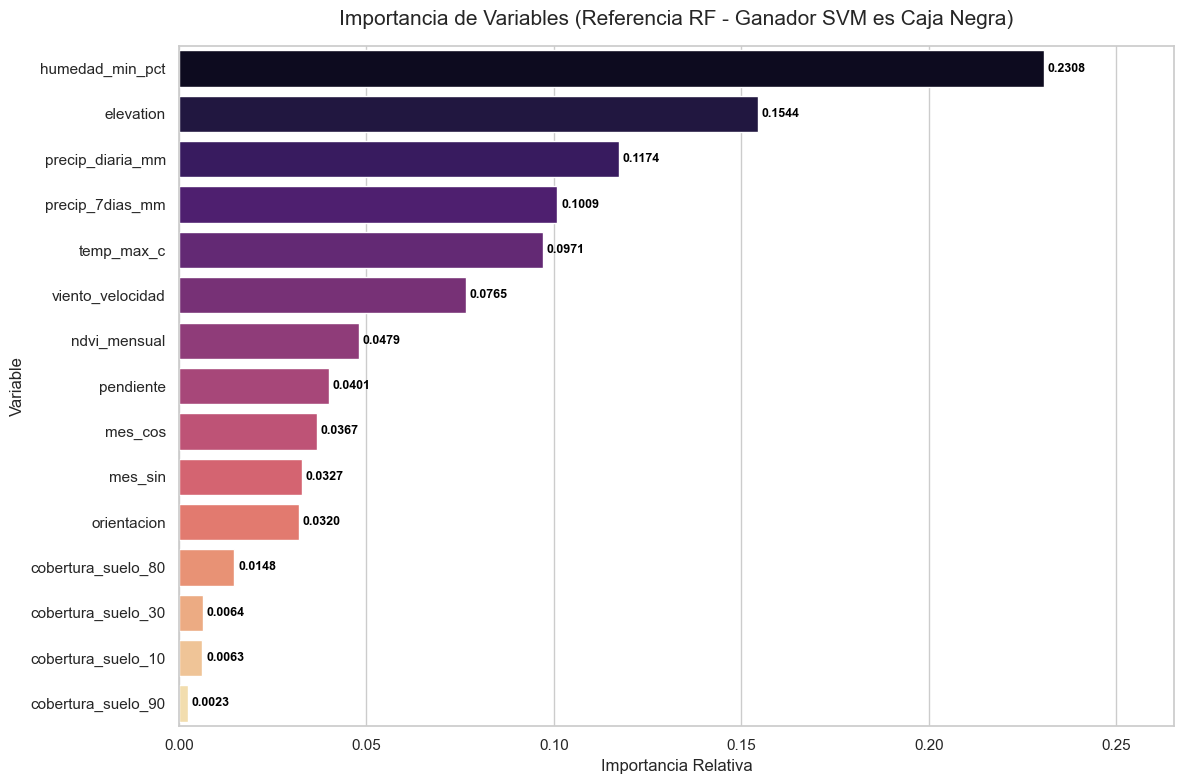

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Configuración estética profesional para tesis
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
ganador_topsis = df_ranking.index[0] # Identificamos el modelo #1 según el ranking

# --- A. GRÁFICO DE BARRAS: COMPARATIVA DE MÉTRICAS ---
# Seleccionamos las métricas de beneficio para graficar
metrics_plot = ['ROC_AUC', 'Recall', 'F1_Score', 'Specificity']
df_plot = df_resultados[metrics_plot].reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', palette='viridis')

# Añadir etiquetas de valor SIEMPRE
for p in ax.patches:
    val = p.get_height()
    if val >= 0: # Quitamos la restricción de "solo si es grande"
        ax.annotate(format(val, '.3f'), 
                       (p.get_x() + p.get_width() / 2., val), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 10), # Un poco más arriba para que no toque la barra
                       textcoords = 'offset points',
                       fontsize=8.5, # Tamaño legible
                       fontweight='bold',
                       rotation=0) # Los dejamos rectos para que se lean bien

plt.title('Rendimiento Comparativo de Modelos (Incluyendo valores críticos)', fontsize=16, pad=20)
plt.ylim(0, 1.1) # Empezamos desde 0 para que se vea la diferencia real de tamaño
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- B. CURVAS ROC: CAPACIDAD DE DISCRIMINACIÓN ---
plt.figure(figsize=(10, 8))

for modelo_name, row in df_resultados.iterrows():
    y_prob = row['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = row['ROC_AUC']
    
    # DESTACAMOS AL GANADOR TOPSIS con una línea más gruesa
    if modelo_name == ganador_topsis:
        plt.plot(fpr, tpr, label=f"★ {modelo_name} (Ganador TOPSIS, AUC={auc_val:.4f})", linewidth=4, color='black', zorder=10)
    else:
        plt.plot(fpr, tpr, label=f"{modelo_name} (AUC={auc_val:.4f})", alpha=0.6, linewidth=1.5)

plt.plot([0, 1], [0, 1], 'r--', alpha=0.4, label='Referencia Aleatoria')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)', fontsize=11)
plt.title(f'Curvas ROC: El modelo {ganador_topsis} presenta el mejor balance', fontsize=15, pad=15)
plt.legend(loc='lower right', fontsize=9)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "curvas_roc_comparativas.png", dpi=300)
plt.show()

# --- C. ANÁLISIS DE IMPORTANCIA DE VARIABLES (CON FALLBACK A RF) ---

nombre_ganador = df_ranking.index[0]
pipeline_ganador = pipelines_entrenados[nombre_ganador]
modelo_final = pipeline_ganador.named_steps['classifier']

# 1. Lógica de selección del modelo para el gráfico
if hasattr(modelo_final, 'feature_importances_'):
    modelo_referencia = modelo_final
    pipeline_referencia = pipeline_ganador
    titulo_grafico = f'Importancia de Variables: Modelo Ganador ({nombre_ganador})'
    print(f"Extrayendo importancia directamente del ganador: {nombre_ganador}")
else:
    # FALLBACK: Si el ganador no soporta importancia, usamos RF como referencia técnica
    modelo_referencia = pipelines_entrenados['RF'].named_steps['classifier']
    pipeline_referencia = pipelines_entrenados['RF']
    titulo_grafico = f'Importancia de Variables (Referencia RF - Ganador {nombre_ganador} es Caja Negra)'
    print(f"El ganador {nombre_ganador} no soporta importancia. Usando Random Forest como referencia.")

# 2. Extracción de datos
importancias = modelo_referencia.feature_importances_
nombres_vars = pipeline_referencia.named_steps['preprocessor'].get_feature_names_out()

df_imp = pd.DataFrame({'Variable': nombres_vars, 'Importancia': importancias})
df_imp['Variable'] = df_imp['Variable'].str.replace('num__', '').str.replace('cat__', '')
df_imp = df_imp.sort_values('Importancia', ascending=False)

# 3. Generación del Gráfico
plt.figure(figsize=(12, 8))
ax_imp = sns.barplot(data=df_imp.head(15), x='Importancia', y='Variable', palette='magma')

# PONER EL NÚMERO SIEMPRE (Aunque sea muy pequeño)
for p in ax_imp.patches:
    width = p.get_width()
    # Ponemos el número justo al final de la barra
    ax_imp.text(width + 0.001, # Un pequeño margen a la derecha
                p.get_y() + p.get_height()/2, 
                format(width, '.4f'), # 4 decimales para ver valores pequeños
                va='center', 
                fontsize=9, 
                fontweight='bold',
                color='black')

plt.title(titulo_grafico, fontsize=15, pad=15)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.xlim(0, df_imp['Importancia'].max() * 1.15) # Espacio para que el texto no se corte
plt.tight_layout()

# Guardar
plt.savefig(OUTPUT_DIR / "importancia_variables_final.png", dpi=300)
plt.show()